In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import copy
from tqdm import tqdm 
import gurobipy as gp 
from gurobipy import GRB
from IPython.display import display, clear_output
import time

from matplotlib.collections import LineCollection




A completely random, un-evolved DNA map scored: 31 / 100


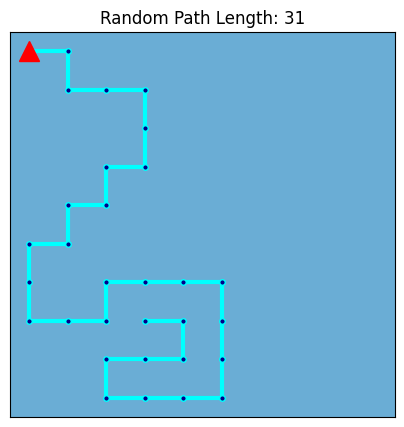

In [ ]:
# ==========================================
# 1. THE DECODER (FITNESS FUNCTION)
# ==========================================
def calculate_fitness(dna_map, base_grid, start_pos=(0, 0)):
    
    # Drops the 'Plumber' into the room. It looks at the dna_map and  always steps on the adjacent tile with the highest priority number.
    # Returns the final score (path length) and the path coordinates.
    
    grid_size = dna_map.shape[0]
    
    # Keep track of where we have been
    visited = np.zeros((grid_size, grid_size), dtype=bool)
    
    # IMPORTANT: Mark any obstacles (-1) as "visited" so the plumber never steps on them
    visited[base_grid == -1] = True 
    
    current_pos = start_pos
    visited[current_pos] = True
    
    # Store the path for visualization later
    path_x = [current_pos[1]]
    path_y = [current_pos[0]]
    
    score = 1 # We start with 1 point for the starting square
    
    # The Pathfinding Loop
    while True:
        r, c = current_pos
        
        # Look North, South, East, West
        neighbors = [(r-1, c), (r+1, c), (r, c-1), (r, c+1)]
        valid_neighbors = []
        
        # Filter out walls and already visited squares
        for nr, nc in neighbors:
            if 0 <= nr < grid_size and 0 <= nc < grid_size:
                if not visited[nr, nc]:
                    valid_neighbors.append((nr, nc))
                    
        # If there are no valid squares left, the plumber is trapped! Stop routing.
        if len(valid_neighbors) == 0:
            break
            
        # Look at the DNA map to find the valid neighbor with the highest number
        best_neighbor = None
        highest_priority = -1.0
        
        for nr, nc in valid_neighbors:
            if dna_map[nr, nc] > highest_priority:
                highest_priority = dna_map[nr, nc]
                best_neighbor = (nr, nc)
                
        # Make the move
        current_pos = best_neighbor
        visited[current_pos] = True
        path_x.append(current_pos[1])
        path_y.append(current_pos[0])
        score += 1
        
    return score, path_x, path_y

# ==========================================
# QUICK TEST: HOW DOES A COMPLETELY RANDOM MAP DO?
# ==========================================
GRID_SIZE = 10
test_base_grid = np.zeros((GRID_SIZE, GRID_SIZE))

# Generate exactly 1 random DNA map
random_dna = np.random.rand(GRID_SIZE, GRID_SIZE)

# Run the Plumber
score, px, py = calculate_fitness(random_dna, test_base_grid, start_pos=(0,0))

print(f"A completely random, un-evolved DNA map scored: {score} / {GRID_SIZE * GRID_SIZE}")

# Quick visualization of the random path
plt.figure(figsize=(5,5))
plt.imshow(test_base_grid, cmap='Blues', vmin=-1, vmax=1)
plt.plot(px, py, color='cyan', linewidth=3, marker='o', markersize=4, markerfacecolor='darkblue')
plt.plot(px[0], py[0], marker='^', color='red', markersize=15) # Start position
plt.title(f"Random Path Length: {score}")
plt.xticks([])
plt.yticks([])
plt.grid(color='white', linestyle='-', linewidth=2)
plt.show()

Target Score: 100


 33%|███▎      | 331/1000 [00:07<00:15, 44.13it/s]



Perfect layout found at generation 331!


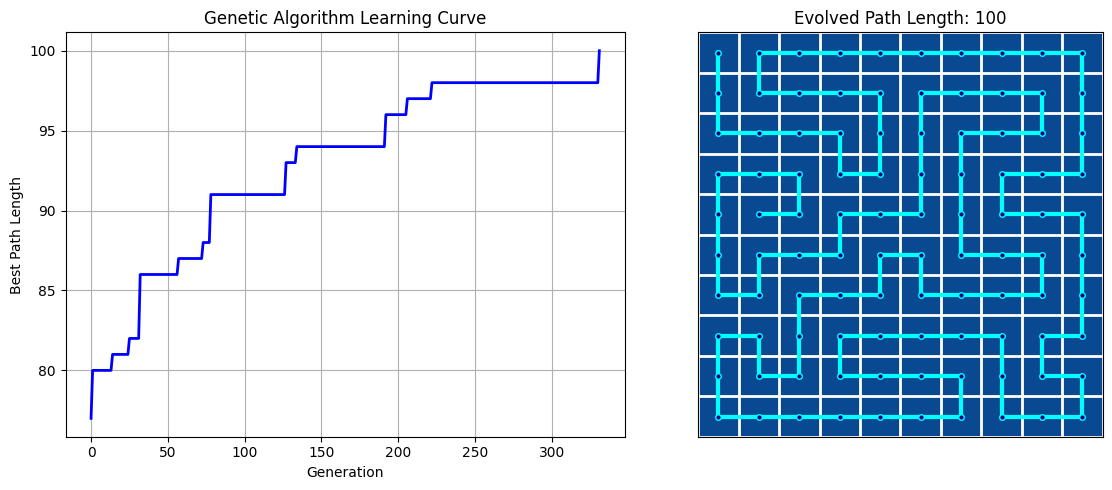

In [ ]:
# ==========================================
# 2. THE EVOLUTION ENGINE (WITH EXTINCTION)
# ==========================================
def create_population(pop_size, grid_size):
    return [np.random.rand(grid_size, grid_size) for _ in range(pop_size)]

def crossover(parent1, parent2):
    mask = np.random.rand(*parent1.shape) > 0.5
    return np.where(mask, parent1, parent2)

def mutate(dna, mutation_rate=0.05):
    mask = np.random.rand(*dna.shape) < mutation_rate
    random_genes = np.random.rand(*dna.shape)
    return np.where(mask, random_genes, dna)

def run_evolution(base_grid, start_pos=(0,0), pop_size=200, generations=500, mutation_rate=0.05):
    grid_size = base_grid.shape[0]
    population = create_population(pop_size, grid_size)
    
    best_dna = None
    best_score = -1
    best_px, best_py = [], []
    history = [] 
    
    max_possible_score = np.sum(base_grid == 0)
    
    print(f"Target Score: {max_possible_score}")
    
    # NEW: Stagnation Tracker
    stagnation_counter = 0 
    
    for gen in tqdm(range(generations)):
        scored_population = []
        for dna in population:
            score, px, py = calculate_fitness(dna, base_grid, start_pos)
            scored_population.append((score, dna, px, py))
            
        # Sort descending by score
        scored_population.sort(key=lambda x: x[0], reverse=True)
        
        # Check the best in this generation
        current_best_score = scored_population[0][0]
        
        if current_best_score > best_score:
            best_score = current_best_score
            best_dna = scored_population[0][1]
            best_px, best_py = scored_population[0][2], scored_population[0][3]
            stagnation_counter = 0 # Reset tracker if we improved!
        else:
            stagnation_counter += 1 # We are stuck!
            
        history.append(best_score)
        
        if best_score == max_possible_score:
            print(f"\n Completely filled layout found at generation {gen}!")
            break
            
        parents = [item[1] for item in scored_population[:50]]
        next_generation = []
        next_generation.extend(parents[:10]) # Elites survive
        
        # ==========================================
        # MASS EXTINCTION EVENT
        # ==========================================
        if stagnation_counter >= 30:
            # The gene pool is stagnant. Wipe out the rest of the population and inject fresh DNA!
            fresh_dna = create_population(pop_size - len(next_generation), grid_size)
            next_generation.extend(fresh_dna)
            stagnation_counter = 0 # Reset tracker after the asteroid hits
        else:
            # Normal breeding
            while len(next_generation) < pop_size:
                p1 = random.choice(parents)
                p2 = random.choice(parents)
                child = crossover(p1, p2)
                child = mutate(child, mutation_rate)
                next_generation.append(child)
            
        population = next_generation
        
    return best_score, best_dna, best_px, best_py, history

# ==========================================
# 3. EXECUTE & VISUALIZE
# ==========================================
# Increase generations slightly to give it time to recover from extinctions
final_score, final_dna, fx, fy, learning_curve = run_evolution(
    test_base_grid, start_pos=(0,0), pop_size=200, generations=1000, mutation_rate=0.05
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(learning_curve, color='blue', linewidth=2)
ax1.set_title("Genetic Algorithm Learning Curve")
ax1.set_xlabel("Generation")
ax1.set_ylabel("Best Path Length")
ax1.grid(True)

# Visual Cleanups: Removed markers, added clean gridlines
vis_grid = np.zeros_like(test_base_grid, dtype=float)
vis_grid[test_base_grid == 0] = 0.9   
vis_grid[test_base_grid == -1] = 0.0  

ax2.imshow(vis_grid, cmap='Blues', vmin=0, vmax=1)
ax2.plot(fx, fy, color='cyan', linewidth=3, marker='o', markersize=4, markerfacecolor='darkblue', zorder=3)

# Gridlines
ax2.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
ax2.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
ax2.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax2.tick_params(which="minor", bottom=False, left=False)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title(f"Evolved Path Length: {final_score}")

plt.tight_layout()
plt.show()

# Show the counterflow (double line) layout 

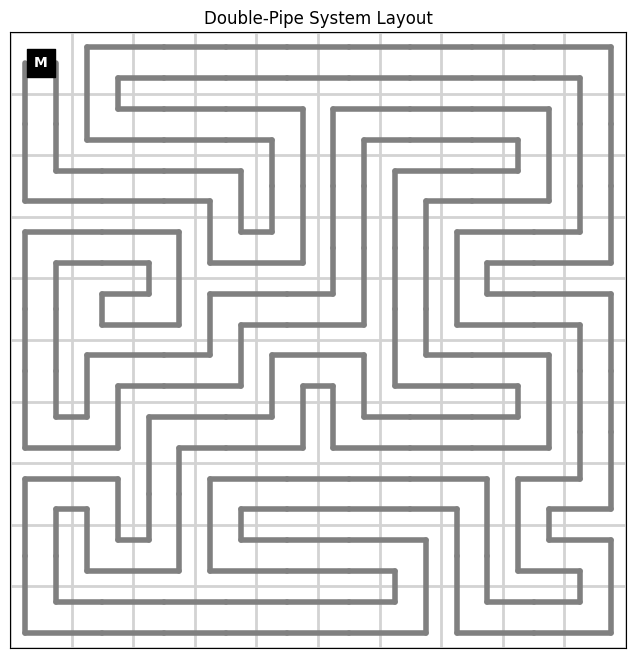

In [ ]:

def draw_solid_double_pipe(base_grid, path_x, path_y, offset=0.25):
    """
    Renders the layout as a parallel supply and return pipe in solid gray
    on a clean background with perfectly mitered corners.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # 1. Clean Background (White floor, Dark Grey obstacles)
    vis_grid = np.zeros_like(base_grid, dtype=float)
    vis_grid[base_grid == 0] = 1.0   
    vis_grid[base_grid == -1] = 0.2  
    ax.imshow(vis_grid, cmap='gray', vmin=0, vmax=1)
    
    grid_size = base_grid.shape[0]
    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which="minor", color="lightgray", linestyle='-', linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xticks([])
    ax.set_yticks([])

    # 2. Perfect Corner Math (Miter Joints)
    n = len(path_x)
    sx, sy = np.zeros(n), np.zeros(n)
    rx, ry = np.zeros(n), np.zeros(n)
    
    for i in range(n):
        if i == 0:
            dx, dy = path_x[1]-path_x[0], path_y[1]-path_y[0]
        elif i == n-1:
            dx, dy = path_x[-1]-path_x[-2], path_y[-1]-path_y[-2]
        else:
            # Average vector to find the exact angle of the corner
            dx1, dy1 = path_x[i]-path_x[i-1], path_y[i]-path_y[i-1]
            dx2, dy2 = path_x[i+1]-path_x[i], path_y[i+1]-path_y[i]
            dx, dy = (dx1 + dx2) / 2.0, (dy1 + dy2) / 2.0
            
        l = np.hypot(dx, dy)
        nx, ny = -dy/l, dx/l # Perpendicular normal
        
        # Miter corner expansion (pushes corners out perfectly 90 deg)
        if i > 0 and i < n-1 and l < 0.99:
            nx /= l
            ny /= l
            
        # Supply offset
        sx[i] = path_x[i] + nx * offset
        sy[i] = path_y[i] + ny * offset
        # Return offset
        rx[i] = path_x[i] - nx * offset
        ry[i] = path_y[i] - ny * offset

    # 3. Build Segments
    sup_segs, ret_segs = [], []
    
    for i in range(n - 1):
        sup_segs.append([(sx[i], sy[i]), (sx[i+1], sy[i+1])])
        ret_segs.append([(rx[i], ry[i]), (rx[i+1], ry[i+1])])

    # Connect the U-turn at the tip of the pipe
    sup_segs.append([(sx[-1], sy[-1]), (rx[-1], ry[-1])])

    # 4. Plot using LineCollection (solid gray)
    ax.add_collection(LineCollection(sup_segs, colors="gray", linewidths=4, capstyle='round', joinstyle='round'))
    ax.add_collection(LineCollection(ret_segs, colors="gray", linewidths=4, capstyle='round', joinstyle='round'))
    
    # 5. Draw the Manifold Connection
    ax.scatter(path_x[0], path_y[0], color='black', s=400, marker='s', zorder=4)
    ax.text(path_x[0], path_y[0], 'M', color='white', ha='center', va='center', fontweight='bold', zorder=5)
    
    plt.title("Double-Pipe System Layout")
    plt.show()

# Run it!
draw_solid_double_pipe(test_base_grid, fx, fy)